# AI Dynamic Pricing Engine

## Objective

The purpose of this notebook is to convert AI demand predictions into actionable pricing recommendations.

Instead of only forecasting demand, the system recommends optimal pricing decisions based on inventory levels, competitor pricing, discounts, and predicted demand.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/retail_store_inventory (1).csv")

df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [2]:
def demand_level(x):
    if x >= 200:
        return "High"
    elif x >= 100:
        return "Medium"
    else:
        return "Low"

df["Demand Level"] = df["Demand Forecast"].apply(demand_level)

df["Demand Level"].value_counts()

Demand Level
Low       33117
Medium    20563
High      19420
Name: count, dtype: int64

In [3]:
def inventory_status(x):
    if x < 100:
        return "Low Inventory"
    elif x < 250:
        return "Medium Inventory"
    else:
        return "High Inventory"

df["Inventory Status"] = df["Inventory Level"].apply(inventory_status)

df["Inventory Status"].value_counts()

Inventory Status
High Inventory      40438
Medium Inventory    24626
Low Inventory        8036
Name: count, dtype: int64

In [4]:
def pricing_recommendation(row):

    # High demand + Low inventory
    if row["Demand Level"] == "High" and row["Inventory Status"] == "Low Inventory":
        return "Increase Price by 8%"

    # Low demand + High inventory
    elif row["Demand Level"] == "Low" and row["Inventory Status"] == "High Inventory":
        return "Reduce Price by 10%"

    # Competitor cheaper
    elif row["Competitor Pricing"] < row["Price"]:
        return "Match Competitor Price"

    # Promotion opportunity
    elif row["Holiday/Promotion"] == 1:
        return "Launch Promotional Discount"

    else:
        return "Maintain Current Price"

In [5]:
df["AI Recommendation"] = df.apply(pricing_recommendation, axis=1)

df[[
    "Price",
    "Competitor Pricing",
    "Demand Level",
    "Inventory Status",
    "AI Recommendation"
]].head(20)

,Price,Competitor Pricing,Demand Level,Inventory Status,AI Recommendation
0,33.50,29.69,Medium,Medium Inventory,Match Competitor Price
1,63.01,66.16,Medium,Medium Inventory,Maintain Current Price
2,27.99,31.32,Low,Medium Inventory,Launch Promotional Discount
3,32.72,34.74,Low,High Inventory,Reduce Price by 10%
4,73.64,68.95,Low,Medium Inventory,Match Competitor Price
5,76.83,79.35,Medium,Medium Inventory,Launch Promotional Discount
6,34.16,36.55,Medium,High Inventory,Launch Promotional Discount
7,97.99,100.09,High,High Inventory,Maintain Current Price
8,20.74,17.66,Medium,Medium Inventory,Match Competitor Price
9,59.99,61.21,Low,Medium Inventory,Launch Promotional Discount


In [6]:
df["AI Recommendation"].value_counts()

AI Recommendation
Match Competitor Price         31149
Maintain Current Price         15727
Launch Promotional Discount    15448
Reduce Price by 10%            10776
Name: count, dtype: int64

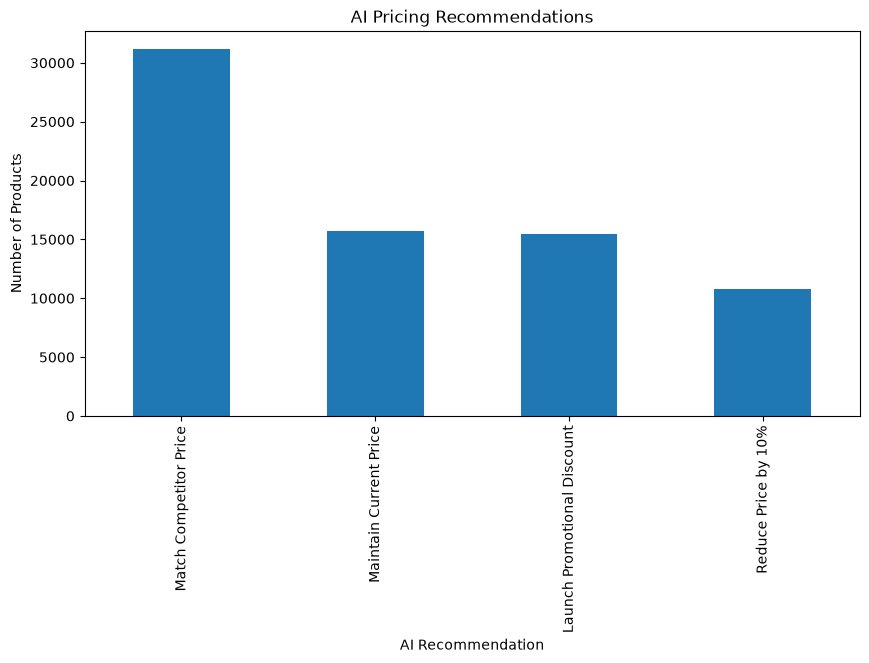

In [7]:
import matplotlib.pyplot as plt

recommendations = df["AI Recommendation"].value_counts()

plt.figure(figsize=(10,5))

recommendations.plot(kind="bar")

plt.title("AI Pricing Recommendations")

plt.ylabel("Number of Products")

plt.show()

## Business Insight

The AI engine transforms raw forecasts into business actions.

Instead of providing only demand predictions, the system recommends pricing strategies that retail managers can immediately implement.

This bridges the gap between predictive analytics and business decision-making.